In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)


## 1. Load Dataset & Exploratory Data Analysis (EDA)

In [2]:
# Load dataset
df = pd.read_csv('train_test_network.csv')
print("Dataset Shape:", df.shape)
print("\nFirst 5 rows of dataset:")
print(df.head())


Dataset Shape: (211043, 44)

First 5 rows of dataset:
          src_ip  src_port         dst_ip  ...  weird_notice label      type
0   192.168.1.37      4444  192.168.1.193  ...             -     1  backdoor
1  192.168.1.193     49180   192.168.1.37  ...             -     1  backdoor
2  192.168.1.193     49180   192.168.1.37  ...             -     1  backdoor
3  192.168.1.193     49180   192.168.1.37  ...             -     1  backdoor
4  192.168.1.193     49180   192.168.1.37  ...             -     1  backdoor

[5 rows x 44 columns]


In [3]:
# Summary statistics and missing values check
print("Missing values in dataset:")
print(df.isnull().sum()[df.isnull().sum() > 0] if df.isnull().sum().sum() > 0 else "No missing values found!")
print("\nMulticlass Target ('type') Class Distribution:")
print(df['type'].value_counts())
print("\nDataset Summary Statistics:")
print(df.describe())


Missing values in dataset:
No missing values found!

Multiclass Target ('type') Class Distribution:
type
normal        50000
backdoor      20000
ddos          20000
dos           20000
injection     20000
password      20000
scanning      20000
ransomware    20000
xss           20000
mitm           1043
Name: count, dtype: int64

Dataset Summary Statistics:
            src_port       dst_port  ...  http_status_code          label
count  211043.000000  211043.000000  ...     211043.000000  211043.000000
mean    38646.519543    3495.153770  ...          0.303905       0.763081
std     19307.271048   10191.624778  ...          8.270377       0.425193
min         1.000000       0.000000  ...          0.000000       0.000000
25%     34608.000000      65.000000  ...          0.000000       1.000000
50%     44754.000000      80.000000  ...          0.000000       1.000000
75%     51133.000000    1253.000000  ...          0.000000       1.000000
max     65528.000000   65467.000000  ...        

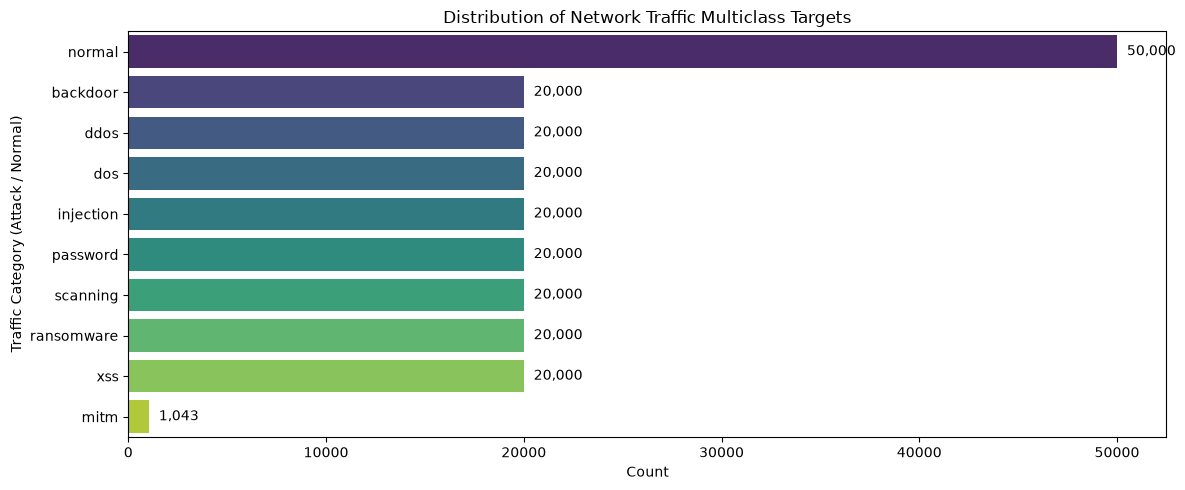

In [4]:
# Data Visualization - Multiclass Target Distribution
plt.figure(figsize=(12, 5))
ax = sns.countplot(y='type', data=df, palette='viridis', order=df['type'].value_counts().index)
plt.title('Distribution of Network Traffic Multiclass Targets')
plt.xlabel('Count')
plt.ylabel('Traffic Category (Attack / Normal)')
for p in ax.patches:
    width = p.get_width()
    ax.annotate(f'{int(width):,}', (width + 500, p.get_y() + p.get_height() / 2.),
                ha='left', va='center')
plt.tight_layout()
plt.show()


## 2. Feature Preprocessing & Scaling

In [5]:
# Separate features and target
# Target is 'type' (10 classes); 'label' is dropped to prevent target leakage
X = df.drop(columns=['label', 'type'])

# Encode target multiclass variable
target_encoder = LabelEncoder()
y = target_encoder.fit_transform(df['type'])
class_names = list(target_encoder.classes_)
num_classes = len(class_names)
print(f"Target Classes ({num_classes}): {class_names}")

# Encode categorical object columns using LabelEncoder
categorical_cols = X.select_dtypes(include=['object']).columns
print(f"Encoding {len(categorical_cols)} categorical features...")
X_encoded = X.copy()
for col in categorical_cols:
    X_encoded[col] = LabelEncoder().fit_transform(X_encoded[col].astype(str))

# Split into train and test sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)

# Feature scaling using StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"X_train shape: {X_train_scaled.shape}, y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test_scaled.shape}, y_test shape: {y_test.shape}")


Target Classes (10): ['backdoor', 'ddos', 'dos', 'injection', 'mitm', 'normal', 'password', 'ransomware', 'scanning', 'xss']
Encoding 26 categorical features...
X_train shape: (168834, 42), y_train shape: (168834,)
X_test shape: (42209, 42), y_test shape: (42209,)


## 3. Building the ANN Model Architecture

In [6]:
def build_ann_multiclass_model(input_dim, num_classes):
    model = Sequential([
        Dense(128, activation='relu', input_shape=(input_dim,)),
        BatchNormalization(),
        Dropout(0.2),
        Dense(64, activation='relu'),
        BatchNormalization(),
        Dropout(0.2),
        Dense(32, activation='relu'),
        BatchNormalization(),
        Dropout(0.1),
        Dense(num_classes, activation='softmax')
    ])
    
    optimizer = Adam(learning_rate=0.001)
    model.compile(
        optimizer=optimizer,
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

model = build_ann_multiclass_model(X_train_scaled.shape[1], num_classes)
model.summary()


Model: "sequential"
┌─────────────────────────────────┬────────────────────────┬───────────────┐
│ Layer (type)                    │ Output Shape           │       Param # │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │         5,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)          

## 4. Model Training

In [7]:
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-5, verbose=1)

history = model.fit(
    X_train_scaled, 
    y_train,
    validation_split=0.15,
    epochs=20,
    batch_size=256,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)


Epoch 1/20

  1/561 ━━━━━━━━━━━━━━━━━━━━ 36:30 4s/step - accuracy: 0.1523 - loss: 2.7355
 10/561 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.2249 - loss: 2.4216  
 18/561 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.2920 - loss: 2.2228
 26/561 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.3410 - loss: 2.0768
 34/561 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.3785 - loss: 1.9630
 42/561 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.4087 - loss: 1.8705
 49/561 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.4308 - loss: 1.8029
 56/561 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.4498 - loss: 1.7445
 66/561 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.4729 - loss: 1.6730
 76/561 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.4923 - loss: 1.6122
 84/561 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.5058 - loss: 1.5694
 93/561 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.5193 - loss: 1.5267
101/561 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.5302 - loss: 1.4925
109/561 ━

## 5. Model Evaluation & Accuracy Metrics

In [8]:
# Predict probabilities on test set
y_pred_prob = model.predict(X_test_scaled)
y_pred = np.argmax(y_pred_prob, axis=1)

# Calculate multiclass performance metrics
accuracy = accuracy_score(y_test, y_pred)
precision_weighted = precision_score(y_test, y_pred, average='weighted')
recall_weighted = recall_score(y_test, y_pred, average='weighted')
f1_weighted = f1_score(y_test, y_pred, average='weighted')
precision_macro = precision_score(y_test, y_pred, average='macro')
recall_macro = recall_score(y_test, y_pred, average='macro')
f1_macro = f1_score(y_test, y_pred, average='macro')

print('=' * 55)
print('  ANN Multiclass Classification Performance Evaluation')
print('=' * 55)
print(f'  Overall Accuracy Score                  : {accuracy:.4f} ({accuracy * 100:.2f}%)')
print(f'  Weighted Precision                      : {precision_weighted:.4f}')
print(f'  Weighted Recall                         : {recall_weighted:.4f}')
print(f'  Weighted F1 Score                       : {f1_weighted:.4f}')
print(f'  Macro F1 Score                          : {f1_macro:.4f}')
print('=' * 55)

if accuracy > 0.90:
    print('\n[SUCCESS] Target Accuracy (>90%) achieved!')
else:
    print('\n[WARNING] Accuracy below 90% threshold.')

print("\nFull Per-Class Classification Report:")
print(classification_report(y_test, y_pred, target_names=class_names))



   1/1320 ━━━━━━━━━━━━━━━━━━━━ 4:25 201ms/step
  23/1320 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step    
  48/1320 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
  73/1320 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
  99/1320 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
 126/1320 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
 153/1320 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
 178/1320 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
 202/1320 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
 226/1320 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
 252/1320 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
 276/1320 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
 298/1320 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
 328/1320 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
 348/1320 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
 366/1320 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
 396/1320 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
 434/1320 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
 461/1320 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
 486/1320 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
 510/1320 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
 533/1320 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
 556/1320 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
 5

## 6. Visualization & Error Analysis

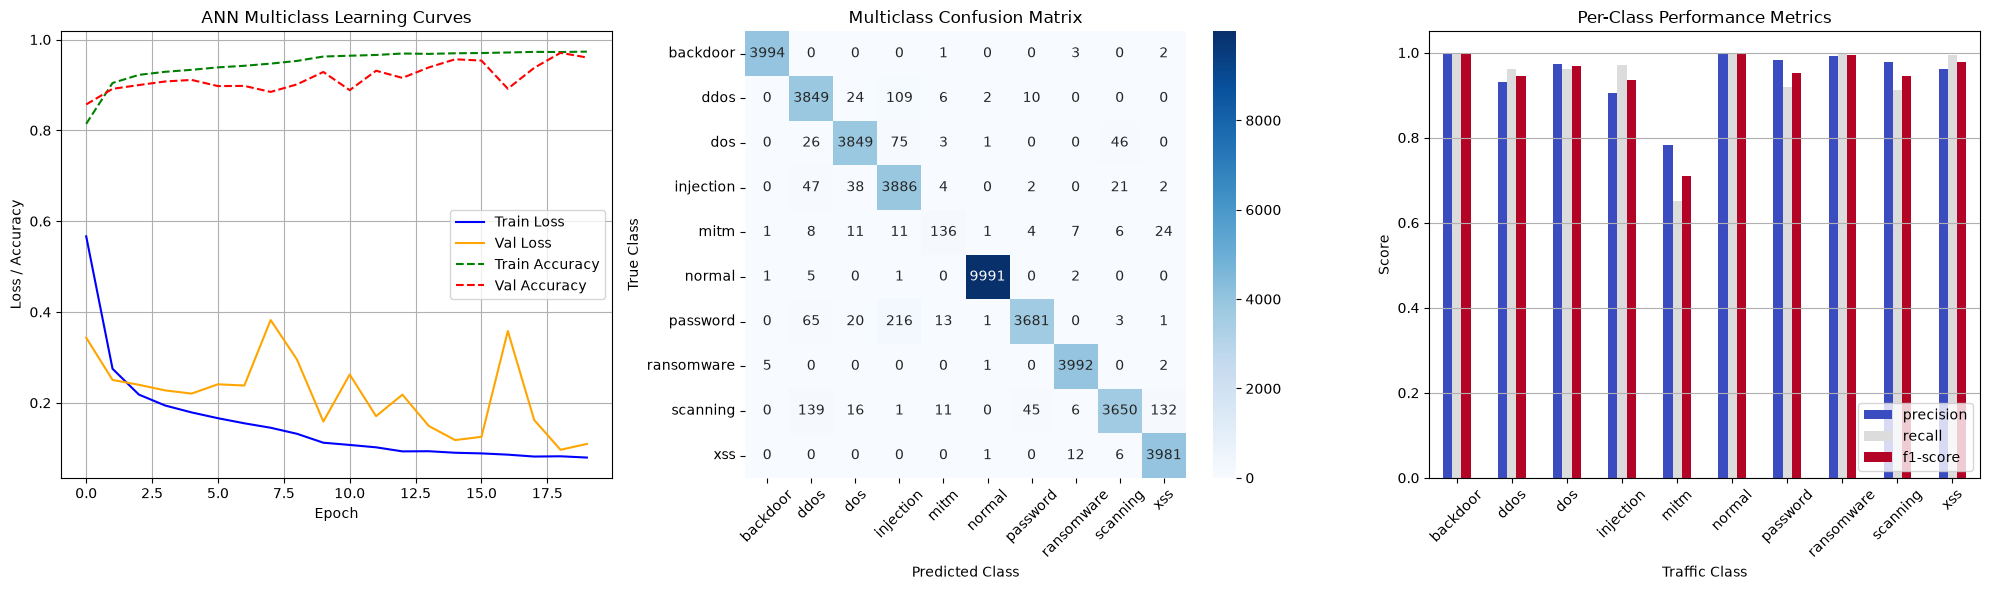

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Plot 1: Training & Validation Loss and Accuracy Curves
axes[0].plot(history.history['loss'], label='Train Loss', color='blue')
axes[0].plot(history.history['val_loss'], label='Val Loss', color='orange')
axes[0].plot(history.history['accuracy'], label='Train Accuracy', linestyle='--', color='green')
axes[0].plot(history.history['val_accuracy'], label='Val Accuracy', linestyle='--', color='red')
axes[0].set_title('ANN Multiclass Learning Curves')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss / Accuracy')
axes[0].legend()
axes[0].grid(True)

# Plot 2: Multiclass Confusion Matrix Heatmap
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=class_names, yticklabels=class_names)
axes[1].set_title('Multiclass Confusion Matrix')
axes[1].set_xlabel('Predicted Class')
axes[1].set_ylabel('True Class')
axes[1].tick_params(axis='x', rotation=45)

# Plot 3: Per-Class Precision & Recall Bar Chart
report_dict = classification_report(y_test, y_pred, target_names=class_names, output_dict=True)
metrics_df = pd.DataFrame(report_dict).T.iloc[:num_classes][['precision', 'recall', 'f1-score']]
metrics_df.plot(kind='bar', ax=axes[2], colormap='coolwarm')
axes[2].set_title('Per-Class Performance Metrics')
axes[2].set_xlabel('Traffic Class')
axes[2].set_ylabel('Score')
axes[2].set_ylim([0.0, 1.05])
axes[2].legend(loc='lower right')
axes[2].tick_params(axis='x', rotation=45)
axes[2].grid(True, axis='y')

plt.tight_layout()
plt.show()
